Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /Users/ye/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/20 [00:00<?, ?it/s]

完成！图像已保存为 test.png


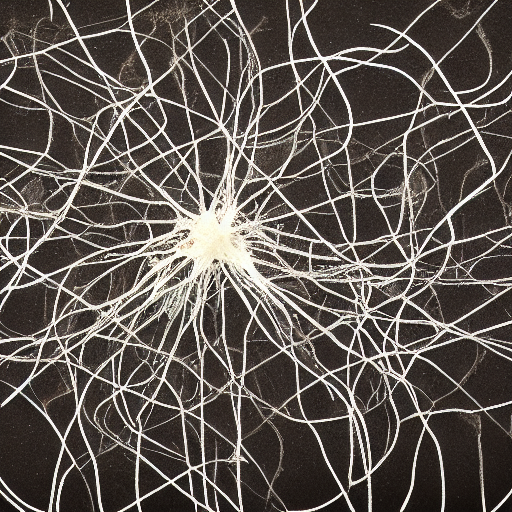

In [ ]:
from diffusers import StableDiffusionPipeline, DDIMScheduler
import torch
from IPython.display import display  # 加这一行

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16,
    safety_checker=None,
    requires_safety_checker=False
)

pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)
pipe = pipe.to("mps")

image = pipe(
    "mycelium network, dark background, organic, white threads",
    num_inference_steps=20,
    guidance_scale=7.5
).images[0]

image.save("test.png")
print("Image saved as test.png")

display(image) 